# Unit 5 — 07: A/B Testing and Canary Deployment for Model Releases

**What you will do:** Build an `ABRouter` that splits traffic between two models, analyze the results with statistical tests, then build a `CanaryDeployment` class that gradually promotes the new model — or rolls it back.

**Why it matters:** Replacing a production model immediately is high-risk. A/B testing and canary deployments let you measure the real impact on live traffic before committing.

**How to run:** Python 3.10+. Run cells in order.

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 08 "Computing P-values and Confidence Intervals" — you learned to decide whether an observed difference is real or noise; an A/B test on live traffic is that same computation, with a rollback decision and real users attached to the answer.

---

## Section 1 — Why Not Replace Model A with Model B Immediately?

A new model may score higher on your held-out test set but still:
- Perform worse on specific user segments not well-represented in test data
- Have higher latency under production load
- Produce confident but wrong predictions on edge cases

**A/B testing** routes a fraction of live traffic to the new model and measures real outcomes side by side.  
**Canary deployment** makes the rollout gradual: 5% → 25% → 100%, with automatic rollback if metrics degrade at any step.

## Section 2 — A/B Testing Setup

In [1]:
# WHAT: train the two contenders (a weak champion A, a stronger candidate B) and
# build the ABRouter that randomly splits traffic between them.
# WHY: an A/B test needs a real difference to detect and an unbiased coin to
# assign requests — both are constructed here.
import numpy as np
import time
from typing import List, Dict, Tuple

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(42)

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model A: current production model. We deliberately under-regularize it
# (small C) so it is a genuinely WEAKER baseline (~0.82 accuracy) — this gives
# the A/B test a real difference to detect, the way an older model would.
model_a = LogisticRegression(C=0.008, max_iter=200, random_state=42)
model_a.fit(X_train, y_train)

# Model B: candidate model (RandomForest — should be better)
model_b = RandomForestClassifier(n_estimators=50, random_state=42)
model_b.fit(X_train, y_train)

print(f"Model A (LogisticRegression) test accuracy: {model_a.score(X_test, y_test):.4f}")
print(f"Model B (RandomForest)        test accuracy: {model_b.score(X_test, y_test):.4f}")


# The router IS the experiment: random assignment per request, nothing else.
class ABRouter:
    """Routes a fraction of traffic to model B; the rest goes to model A."""

    def __init__(self, model_a: object, model_b: object, b_fraction: float = 0.10):
        self.model_a = model_a
        self.model_b = model_b
        self.b_fraction = b_fraction
        self._rng = np.random.default_rng(0)

    def predict(self, X: np.ndarray) -> Tuple[int, str, float]:
        """
        Returns (prediction, model_used, confidence).
        model_used is 'A' or 'B'.
        """
        use_b = self._rng.random() < self.b_fraction
        model = self.model_b if use_b else self.model_a
        proba = model.predict_proba(X.reshape(1, -1))[0]
        prediction = int(np.argmax(proba))
        confidence = float(np.max(proba))
        model_used = "B" if use_b else "A"
        return prediction, model_used, confidence


router = ABRouter(model_a, model_b, b_fraction=0.50)
print(f"\nABRouter created: 50/50 A/B split so both arms get enough samples to compare.")

Model A (LogisticRegression) test accuracy: 0.8222
Model B (RandomForest)        test accuracy: 1.0000

ABRouter created: 50/50 A/B split so both arms get enough samples to compare.


In [2]:
# WHAT: push 1000 requests through the router, logging model used, correctness,
# confidence, and latency for each.
# WHY: this log is the experiment's raw data — the split counts confirm the
# router honored the 50/50 assignment.
# Simulate 1000 requests through the router
N_REQUESTS = 1000
request_log: List[Dict] = []

for i in range(N_REQUESTS):
    idx = rng.integers(0, len(X_test))
    X_sample = X_test[idx]
    true_label = int(y_test[idx])

    t0 = time.perf_counter()
    prediction, model_used, confidence = router.predict(X_sample)
    latency_ms = (time.perf_counter() - t0) * 1000

    request_log.append({
        "model": model_used,
        "prediction": prediction,
        "true_label": true_label,
        "correct": prediction == true_label,
        "confidence": confidence,
        "latency_ms": latency_ms,
    })

a_logs = [r for r in request_log if r["model"] == "A"]
b_logs = [r for r in request_log if r["model"] == "B"]

print(f"Total requests: {N_REQUESTS}")
print(f"  Served by Model A: {len(a_logs)}")
print(f"  Served by Model B: {len(b_logs)}")

Total requests: 1000
  Served by Model A: 527
  Served by Model B: 473


## Section 3 — Analyze A/B Results

                        Requests  Accuracy  Mean Confidence  Mean Latency (ms)  p95 Latency (ms)
Model                                                                                           
A (LogisticRegression)       527    0.8159           0.5234             0.0322            0.0393
B (RandomForest)             473    1.0000           0.9762             1.2543            1.3103


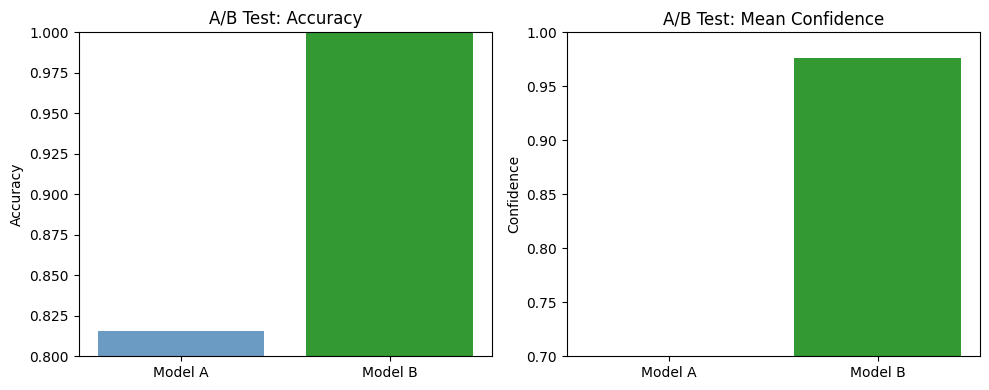

In [3]:
# WHAT: summarize each arm — accuracy, confidence, latency — in one table and chart.
# WHY: eyeballing the gap comes FIRST, but the next cell asks the essential
# question: is this difference real or just luck of the traffic split?
import pandas as pd


def summarize_logs(logs: List[Dict], label: str) -> Dict:
    accuracy = np.mean([r["correct"] for r in logs])
    mean_confidence = np.mean([r["confidence"] for r in logs])
    mean_latency = np.mean([r["latency_ms"] for r in logs])
    p95_latency = np.percentile([r["latency_ms"] for r in logs], 95)
    return {
        "Model": label,
        "Requests": len(logs),
        "Accuracy": round(accuracy, 4),
        "Mean Confidence": round(mean_confidence, 4),
        "Mean Latency (ms)": round(mean_latency, 4),
        "p95 Latency (ms)": round(p95_latency, 4),
    }


summary_a = summarize_logs(a_logs, "A (LogisticRegression)")
summary_b = summarize_logs(b_logs, "B (RandomForest)")

df_summary = pd.DataFrame([summary_a, summary_b]).set_index("Model")
print(df_summary.to_string())

# Plot accuracy and confidence
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Model A", "Model B"],
            [summary_a["Accuracy"], summary_b["Accuracy"]],
            color=["steelblue", "green"], alpha=0.8)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title("A/B Test: Accuracy")
axes[0].set_ylabel("Accuracy")

axes[1].bar(["Model A", "Model B"],
            [summary_a["Mean Confidence"], summary_b["Mean Confidence"]],
            color=["steelblue", "green"], alpha=0.8)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_title("A/B Test: Mean Confidence")
axes[1].set_ylabel("Confidence")

plt.tight_layout()
plt.savefig("/tmp/ab_test_results.png", dpi=72)
plt.show()

## Section 4 — Statistical Significance Test

Model B may look better in the A/B data, but is the difference statistically significant or just random variation? Use a two-proportion z-test to check.

In [4]:
# WHAT: run a two-proportion z-test on the two arms' accuracy.
# WHY: this is the statistics that separates 'B looks better' from 'B IS better
# at alpha=0.05' — the difference between an anecdote and a decision.
from scipy import stats as sp_stats


def two_proportion_z_test(n_a: int, correct_a: int, n_b: int, correct_b: int) -> Dict:
    """
    Two-proportion z-test: is Model B's accuracy significantly different from Model A's?
    H0: p_B == p_A
    """
    p_a = correct_a / n_a
    p_b = correct_b / n_b
    p_pool = (correct_a + correct_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
    z_stat = (p_b - p_a) / se if se > 0 else 0.0
    # Two-tailed p-value
    p_value = 2 * (1 - sp_stats.norm.cdf(abs(z_stat)))
    return {
        "accuracy_a": round(p_a, 4),
        "accuracy_b": round(p_b, 4),
        "z_statistic": round(z_stat, 4),
        "p_value": round(p_value, 6),
        "significant_at_0.05": p_value < 0.05,
    }


# Feed the test raw counts, not percentages — sample size is half the story.
n_a = len(a_logs)
correct_a = sum(r["correct"] for r in a_logs)
n_b = len(b_logs)
correct_b = sum(r["correct"] for r in b_logs)

result = two_proportion_z_test(n_a, correct_a, n_b, correct_b)

print("Two-proportion z-test results:")
for k, v in result.items():
    print(f"  {k}: {v}")

print()
# Read the verdict: significance plus DIRECTION decides promote vs keep testing.
if result["significant_at_0.05"]:
    if result["accuracy_b"] > result["accuracy_a"]:
        print("CONCLUSION: Model B is significantly BETTER than Model A at alpha=0.05.")
    else:
        print("CONCLUSION: Model B is significantly WORSE than Model A at alpha=0.05.")
else:
    print("CONCLUSION: No statistically significant difference detected.")
    print(f"  (Need more data — try n_b >= {int(n_a * 0.5)} before concluding.)")

Two-proportion z-test results:
  accuracy_a: 0.8159
  accuracy_b: 1.0
  z_statistic: 9.819
  p_value: 0.0
  significant_at_0.05: True

CONCLUSION: Model B is significantly BETTER than Model A at alpha=0.05.


## Section 5 — Canary Deployment

A canary deployment shifts traffic gradually: 5% → 10% → 25% → 50% → 100%, checking metrics at each stage. If metrics degrade, roll back.

**What to gate on:** at 5% traffic the *blended* overall accuracy is 95% old model — a bad canary barely moves it, and a good canary can't lift it. The honest gate compares the **canary slice's own accuracy** against the old model's baseline: promote while the canary is not worse (within a small margin), roll back the moment it degrades. We demonstrate both outcomes below — a good canary that gets promoted stage by stage, and a bad one that gets rolled back at the first gate.

In [5]:
# Canary deployment: gradually shift traffic to the new model, gating each
# stage on the CANARY SLICE's accuracy vs the old model's baseline.
class CanaryDeployment:
    """
    Manages a gradual rollout from old_model to new_model.
    fraction = fraction of traffic routed to new_model (0.0 to 1.0).
    """

    STAGES = [0.05, 0.10, 0.25, 0.50, 1.00]

    def __init__(self, old_model: object, new_model: object, initial_fraction: float = 0.05):
        self.old_model = old_model
        self.new_model = new_model
        self.fraction = initial_fraction
        self._stage_idx = 0
        self._rng = np.random.default_rng(7)

    # Route one request: a weighted coin decides old vs new model.
    def predict(self, X: np.ndarray) -> Tuple[int, str]:
        # Route this request to new or old model according to the traffic fraction
        use_new = self._rng.random() < self.fraction
        model = self.new_model if use_new else self.old_model
        prediction = int(model.predict(X.reshape(1, -1))[0])
        return prediction, "new" if use_new else "old"

    # Advance to the next traffic stage (5 -> 10 -> 25 -> 50 -> 100%).
    def promote(self) -> None:
        """Move to the next traffic stage."""
        self._stage_idx = min(self._stage_idx + 1, len(self.STAGES) - 1)
        self.fraction = self.STAGES[self._stage_idx]

    # Emergency exit: instantly return all traffic to the old model.
    def rollback(self) -> None:
        """Immediately route all traffic back to old model."""
        self.fraction = 0.0
        self._stage_idx = 0
        print("  ROLLED BACK: 100% traffic back to old model.")

    def status(self) -> str:
        return f"Stage {self._stage_idx}: {self.fraction*100:.0f}% new model traffic"


# Grades each stage on the canary SLICE's own accuracy, not the blended number
# — blending would hide a bad new model behind the old one's traffic share.
def evaluate_canary(
    canary: CanaryDeployment,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
    n_samples: int = 300,
) -> Dict:
    """Run n_samples requests through the canary; report blended AND per-slice accuracy."""
    logs = []
    indices = rng.integers(0, len(X_eval), size=n_samples)
    for idx in indices:
        pred, model_used = canary.predict(X_eval[idx])
        logs.append({"model": model_used, "correct": pred == int(y_eval[idx])})

    new_logs = [r for r in logs if r["model"] == "new"]
    overall_acc = float(np.mean([r["correct"] for r in logs]))
    new_acc = float(np.mean([r["correct"] for r in new_logs])) if new_logs else float("nan")
    return {"overall_accuracy": overall_acc, "new_model_accuracy": new_acc,
            "n": n_samples, "n_new": len(new_logs)}


# The full rollout loop: evaluate a stage, promote if the gate holds,
# roll back the moment the canary slice falls below the gate.
def run_canary_rollout(old_model, new_model, X_eval, y_eval, margin: float = 0.02):
    """Walk the canary through its stages, gating each on the canary slice.

    Gate: the new model's slice accuracy must stay within `margin` of the old
    model's baseline accuracy. Returns the per-stage results for plotting."""
    baseline_acc = float(old_model.score(X_eval, y_eval))
    gate = baseline_acc - margin
    print(f"Old-model baseline accuracy: {baseline_acc:.3f}  (gate: canary slice >= {gate:.3f})")
    print("-" * 76)

    canary = CanaryDeployment(old_model, new_model, initial_fraction=0.05)
    results = []
    while True:
        m = evaluate_canary(canary, X_eval, y_eval, n_samples=300)
        print(f"  {canary.status():<36} overall={m['overall_accuracy']:.3f}  "
              f"canary_slice={m['new_model_accuracy']:.3f} (n={m['n_new']})")
        results.append({"stage": canary.fraction,
                        "overall": m["overall_accuracy"],
                        "new_slice": m["new_model_accuracy"]})

        # Gate on the canary's OWN slice — the blend hides its quality at 5%
        if m["new_model_accuracy"] < gate:
            canary.rollback()
            break
        if canary.fraction == 1.0:
            print("  FULLY PROMOTED: new model now serves 100% of traffic.")
            break
        canary.promote()
    return results, gate


# Two runs prove both paths: promotion for a good model, rollback for a bad one.
print("Scenario 1 — GOOD canary (new model is stronger): expect stage-by-stage promotion")
stage_results, gate_line = run_canary_rollout(model_a, model_b, X_test, y_test)

print()
print("Scenario 2 — BAD canary (deploying the weak model over the strong one): expect rollback")
bad_results, _ = run_canary_rollout(model_b, model_a, X_test, y_test)

Scenario 1 — GOOD canary (new model is stronger): expect stage-by-stage promotion
Old-model baseline accuracy: 0.822  (gate: canary slice >= 0.802)
----------------------------------------------------------------------------
  Stage 0: 5% new model traffic        overall=0.837  canary_slice=1.000 (n=17)
  Stage 1: 10% new model traffic       overall=0.857  canary_slice=1.000 (n=24)


  Stage 2: 25% new model traffic       overall=0.863  canary_slice=1.000 (n=86)


  Stage 3: 50% new model traffic       overall=0.917  canary_slice=1.000 (n=148)
  Stage 4: 100% new model traffic      overall=1.000  canary_slice=1.000 (n=300)
  FULLY PROMOTED: new model now serves 100% of traffic.

Scenario 2 — BAD canary (deploying the weak model over the strong one): expect rollback
Old-model baseline accuracy: 1.000  (gate: canary slice >= 0.980)
----------------------------------------------------------------------------
  Stage 0: 5% new model traffic        overall=0.990  canary_slice=0.824 (n=17)
  ROLLED BACK: 100% traffic back to old model.


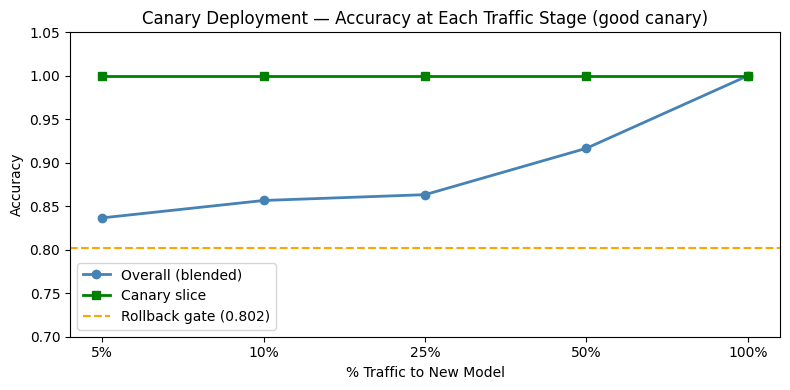

In [6]:
# Visualise scenario 1 (the good canary): accuracy at every traffic stage.
stages = [f"{int(s['stage']*100)}%" for s in stage_results]
overall = [s["overall"] for s in stage_results]
new_slice = [s["new_slice"] for s in stage_results]

plt.figure(figsize=(8, 4))
# Blended accuracy rises as more traffic reaches the better model
plt.plot(stages, overall, marker="o", color="steelblue", linewidth=2, label="Overall (blended)")
# The canary slice itself is what the gate watches
plt.plot(stages, new_slice, marker="s", color="green", linewidth=2, label="Canary slice")
# The rollback line: old-model baseline minus the tolerance margin
plt.axhline(gate_line, color="orange", linestyle="--", label=f"Rollback gate ({gate_line:.3f})")
plt.title("Canary Deployment — Accuracy at Each Traffic Stage (good canary)")
plt.xlabel("% Traffic to New Model")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/canary_stages.png", dpi=72)
plt.show()


## Section 6 — Rollback Criteria

Define explicit, measurable conditions that trigger an automatic rollback.

In [7]:
# WHAT: codify the rollback decision — error-rate delta and latency conditions
# with three worked scenarios.
# WHY: rollback criteria must be written BEFORE the rollout; at 3 a.m. nobody
# should be debating thresholds — the function already knows.
def should_rollback(
    old_error_rate: float,
    new_error_rate: float,
    error_rate_delta_threshold: float = 0.005,  # 0.5 percentage points
    new_p99_latency_ms: float = 0.0,
    latency_threshold_ms: float = 500.0,
) -> Tuple[bool, str]:
    """
    Returns (True, reason) if rollback criteria are met, else (False, 'OK').
    """
    if new_error_rate > old_error_rate + error_rate_delta_threshold:
        delta = new_error_rate - old_error_rate
        return True, (
            f"New model error rate {new_error_rate:.3f} exceeds old model "
            f"by {delta:.3f} (threshold={error_rate_delta_threshold})"
        )
    if new_p99_latency_ms > latency_threshold_ms:
        return True, (
            f"New model p99 latency {new_p99_latency_ms:.1f}ms > threshold {latency_threshold_ms:.1f}ms"
        )
    return False, "OK — no rollback needed"


# Below the delta threshold: tolerated. Scenario 2 crosses it; 3 fails on latency.
# Scenario 1: New model is slightly worse on error rate
rollback, reason = should_rollback(old_error_rate=0.05, new_error_rate=0.058)
print(f"Scenario 1 — Rollback? {rollback}: {reason}")

# Scenario 2: New model error rate exceeds threshold
rollback, reason = should_rollback(old_error_rate=0.05, new_error_rate=0.062)
print(f"Scenario 2 — Rollback? {rollback}: {reason}")

# Scenario 3: New model is accurate but too slow
rollback, reason = should_rollback(old_error_rate=0.05, new_error_rate=0.04, new_p99_latency_ms=600)
print(f"Scenario 3 — Rollback? {rollback}: {reason}")

Scenario 1 — Rollback? True: New model error rate 0.058 exceeds old model by 0.008 (threshold=0.005)
Scenario 2 — Rollback? True: New model error rate 0.062 exceeds old model by 0.012 (threshold=0.005)
Scenario 3 — Rollback? True: New model p99 latency 600.0ms > threshold 500.0ms


## Summary

| Strategy | How it works | When to use |
|---|---|---|
| **A/B test** | Split traffic between A and B; collect metrics; run statistical test | When you want to compare two models with statistical confidence |
| **Canary** | Gradually shift traffic 5% → 100%, gating each stage on the canary slice's own metrics vs the old baseline; roll back on degradation | When you want to limit blast radius of a bad release |

Key principle: **never make promotion automatic without a statistical gate**. The z-test (or chi-squared test) tells you whether observed differences are real or sampling noise.

## Self-Check (answer before scrolling back up)

1. **What sample size do you need before an A/B test is statistically valid?**  
   It depends on the effect size you want to detect and your desired statistical power (typically 80%) and significance level (typically 5%). For a typical ML model with 95% accuracy trying to detect a 1-2% improvement, you usually need several hundred requests per variant minimum. Use a power calculator with your baseline conversion rate and expected delta to get the exact number.

2. **What is the difference between an A/B test and a canary deployment?**  
   An A/B test is primarily a measurement tool — you run both models simultaneously and compare outcomes statistically. A canary deployment is primarily a risk management tool — you shift traffic gradually and roll back if anything goes wrong. They are complementary: you might run an A/B test at the 10% canary stage to validate the decision before promoting to 100%.

3. **If your canary deployment shows higher accuracy but also higher latency, what do you do?**  
   Do not promote automatically. Decide based on your SLOs and business priorities: if the latency exceeds your p99 SLO, roll back and investigate the latency issue separately (batching, model compression, hardware upgrade). If the latency is within SLO but higher than before, weigh the accuracy gain against the latency cost for your specific use case.

## 📚 References

1. Kohavi, R., Longbotham, R., Sommerfield, D., & Henne, R. M. (2009). *Controlled Experiments on the Web: Survey and Practical Guide*. Data Mining and Knowledge Discovery 18(1). <https://doi.org/10.1007/s10618-008-0114-1>
2. Tang, D., Agarwal, A., O'Brien, D., & Meyer, M. (2010). *Overlapping Experiment Infrastructure: More, Better, Faster Experimentation*. KDD. <https://research.google/pubs/overlapping-experiment-infrastructure-more-better-faster-experimentation/>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
